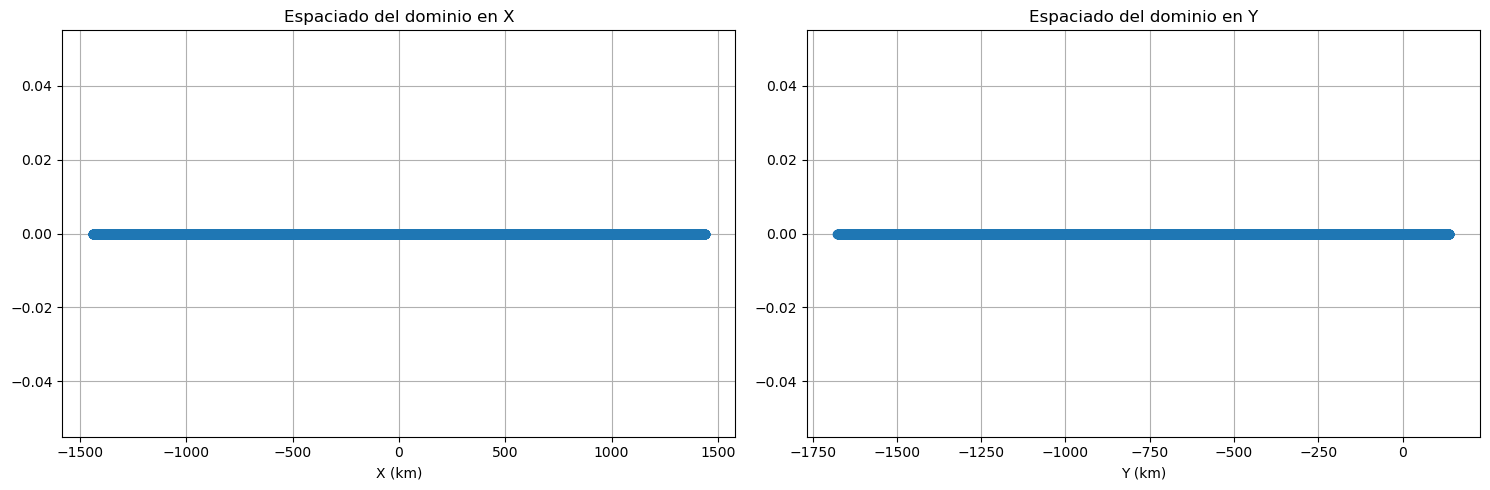

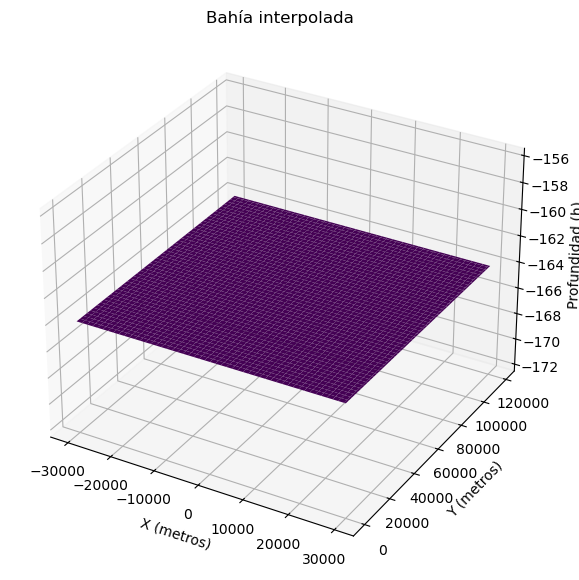

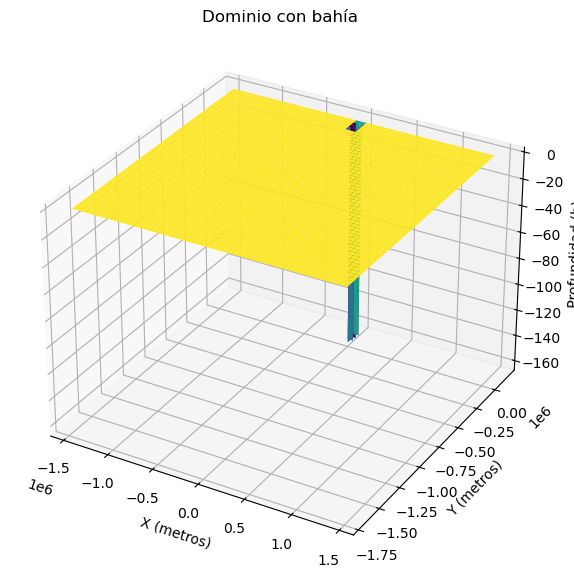

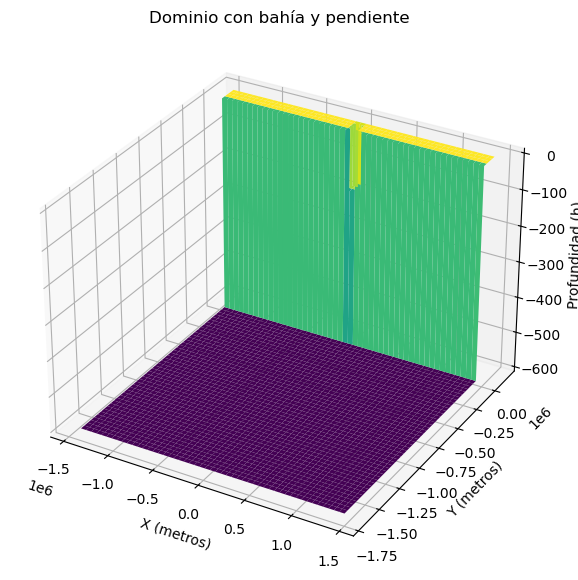

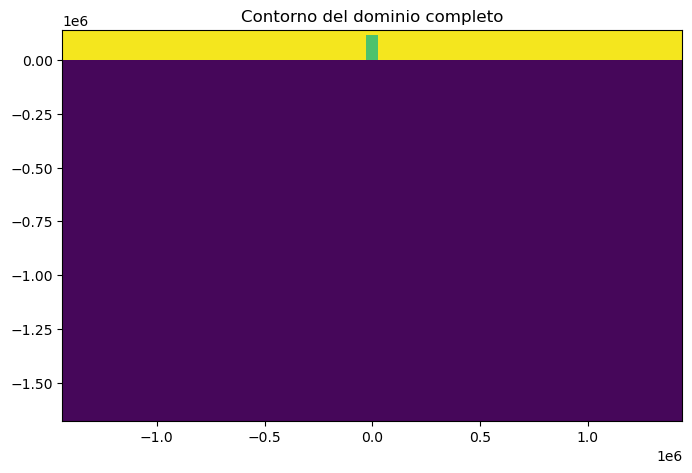

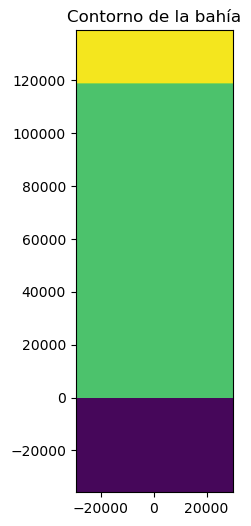

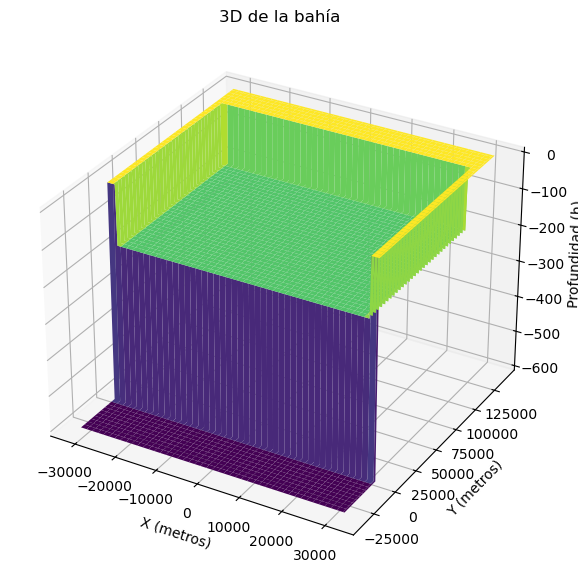

Datos guardados exitosamente en bahia01_expand_bat.nc
1.0, 1.0, 1.1, 1.1, 1.2, 1.2, 1.3, 1.3, 1.4, 1.5, 
1.5, 1.6, 1.7, 1.7, 1.8, 1.9, 2.0, 2.0, 2.1, 
2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.9, 3.0, 3.1, 
3.2, 3.4, 3.5, 3.7, 3.8, 4.0, 4.2, 4.4, 4.5, 
4.7, 4.9, 5.2, 5.4, 5.6, 5.8, 6.1, 6.4, 6.6, 
6.9, 7.2, 7.5, 7.8, 8.2, 8.5, 8.9, 9.3, 9.7, 
10.1, 10.5, 11.0, 11.4, 11.9, 12.5, 13.0, 13.5, 14.1, 
14.7, 15.4, 16.0, 16.7, 17.4, 18.2, 19.0, 19.8, 20.6, 
21.5, 22.4, 23.4, 24.4, 25.4, 26.5, 27.7, 28.9, 30.1, 
31.4, 32.7, 34.2, 35.6, 37.1, 38.7, 40.5, 42.2, 
Suma total (aprox): 1000.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter
import netCDF4 as nc

# =============================================================================
# Función para definir y retornar los parámetros básicos
# =============================================================================
def get_parameters():
    # Parámetros del dominio y batimetría
    h1 = 164 
    L = 119000 
    Y_fondo = -62000
    Fondo_lineal = -440000
    Costa_extra = 20000
    L_expansion = 2 * L
    DelX = 200  # Espaciado en X
    DelY = 200  # Espaciado en Y

    # Cálculo de la cantidad de puntos en la parte central
    nx_center = int(4 * L / DelX)
    ny = int((L + Costa_extra + 4*L) / DelY)
    
    
    # Se retorna además los parámetros para la expansión de dominio
    return {
        'h1': h1, 'L': L, 'Y_fondo': Y_fondo, 'Fondo_lineal': Fondo_lineal,
        'Costa_extra': Costa_extra, 'L_expansion': L_expansion,
        'DelX': DelX, 'DelY': DelY, 'nx_center': nx_center, 'ny': ny,
        'ny_expand': 6000 #antes 30
    }

# =============================================================================
# Función para crear el dominio completo (X e Y) y su malla
# =============================================================================
def create_domain(params):
    h1 = params['h1']
    L = params['L']
    Y_fondo = params['Y_fondo']
    Fondo_lineal = params['Fondo_lineal']
    Costa_extra = params['Costa_extra']
    L_expansion = params['L_expansion']
    DelX = params['DelX']
    DelY = params['DelY']
    nx_center = params['nx_center']
    ny = params['ny']
    ny_expand = params['ny_expand']
    
    # Definir rangos para el dominio central y de expansión
    x_min_center = -L_expansion
    x_max_center = L_expansion
    y_min = -int(4*L)
    
    # Crecimiento iterativo de Δx en la región de expansión X
    factor_x = 1
    n_expand_x = ny_expand
    dx = np.zeros(n_expand_x)
    dx[0] = DelX
    for ii in range(1, n_expand_x):
        dx[ii] = dx[ii-1] * factor_x
    x_offsets = np.cumsum(dx)
    x_right = x_max_center + x_offsets
    x_left = -np.flip(x_right)

    # Crecimiento iterativo de Δy en la región de expansión Y
    factor_y = 1
    n_expand_y = ny_expand + 1
    dy = np.zeros(n_expand_y)
    dy[0] = DelY
    for jj in range(1, n_expand_y):
        dy[jj] = dy[jj-1] * factor_y
    y_offsets = np.cumsum(dy)
    y_expand = y_min - y_offsets
    y_expand = np.flip(y_expand)
    
    # Eliminar valores superpuestos
    x_left = x_left[:-1]
    x_right = x_right[1:]
    y_expand = y_expand[:-1]
    
    # Dominio central con espaciado uniforme
    x_center = np.linspace(x_min_center, x_max_center, nx_center)
    y_center = np.linspace(-4*L, L + Costa_extra, ny)
    
    # Combinar regiones para formar el dominio completo
    x_domain = np.concatenate((x_left, x_center, x_right))
    y_domain = np.concatenate((y_expand, y_center))
    
    # Crear malla 2D y dominio inicial Z (todo en cero)
    X_domain, Y_domain = np.meshgrid(x_domain, y_domain)
    Z_domain = np.zeros_like(X_domain)
    
    return x_domain, y_domain, X_domain, Y_domain, Z_domain, x_left, x_center, x_right, y_expand

# =============================================================================
# Función para graficar el espaciado de los dominios en X y Y
# =============================================================================
def plot_domain_spacing(x_domain, y_domain):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(x_domain/1E3, np.zeros_like(x_domain), 'o-')
    ax1.set_title("Espaciado del dominio en X")
    ax1.set_xlabel("X (km)")
    ax1.grid(True)
    
    ax2.plot(y_domain/1E3, np.zeros_like(y_domain), 'o-')
    ax2.set_title("Espaciado del dominio en Y")
    ax2.set_xlabel("Y (km)")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# Función para calcular la batimetría de la bahía en coordenadas polares y
# su interpolación en un dominio cartesiano refinado
# =============================================================================
def compute_bahia(h1, L, DelX, DelY):
    """
    Construye la batimetría de una bahía rectangular de dimensión L y profundidad h1.
    La dirección X se define de -L/4 a L/4 y la dirección Y se extiende de 0 a L.
    La profundidad es constante (-h1).
    """
    # Calcular el número de puntos en cada dirección basados en el espaciado.
    # Para la dirección x, el rango es L/2 (de -L/4 a L/4)
    nx = int((L/2) / DelX)
    # Para la dirección y, el rango es L (de 0 a L)
    ny = int(L / DelY)
    
    # Definir las coordenadas según el nuevo rango
    x = np.linspace(-L/4, L/4, nx)
    y = np.linspace(0, L, ny)
    X, Y = np.meshgrid(x, y)
    
    # Asignar una profundidad constante a toda la bahía.
    Z_bahia = -np.full_like(X, h1)
    
    return X, Y, Z_bahia


# =============================================================================
# Función para insertar la bahía calculada en el dominio global
# =============================================================================
def insert_bahia(Z_domain, Z_bahia, x_domain, DelX, ny_expand, Y_fondo, Fondo_lineal, L, DelY):
    # Calcular índices en X para ubicar la bahía en el dominio global
    X_idx_start_bahia =  len(x_domain)//2 - int((L/4) / DelX)
    X_idx_end = X_idx_start_bahia + Z_bahia.shape[1]+1 
    
    # Calcular el índice en Y para la bahía
    Idx_bahia_start = ny_expand + int(np.abs(4*L) / DelY) - 1
    Y_idx_end_bahia = Idx_bahia_start + Z_bahia.shape[0]

    Z_domain[Idx_bahia_start:Y_idx_end_bahia, X_idx_start_bahia:X_idx_end] = -164
    
    #Z_domain[Idx_bahia_start:Y_idx_end_bahia, X_idx_start_bahia:X_idx_end] = Z_bahia
    return Z_domain, X_idx_start_bahia, X_idx_end, Idx_bahia_start

# =============================================================================
# Función para agregar el fondo al dominio
# =============================================================================
def add_bottom(Z_domain, Idx_bahia_start):
    # Se asigna un valor fijo en la parte superior
    Z_domain[:Idx_bahia_start+1, :] = -1000
    return Z_domain

# =============================================================================
# Funciones de graficación
# =============================================================================
def plot_3d_surface(X, Y, Z, title='Surface'):
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, Z, cmap='viridis')
    ax.set_xlabel('X (metros)')
    ax.set_ylabel('Y (metros)')
    ax.set_zlabel('Profundidad (h)')
    ax.set_title(title)
    plt.show()

def plot_contours(X, Y, Z, title="Contour Plot"):
    fig, ax = plt.subplots(figsize=(8, 6))
    cf = ax.contourf(X, Y, Z, 33, cmap='viridis')
    ax.contour(X, Y, Z, levels=np.arange(0, 1600, 50), colors='k')
    ax.set_title(title)
    ax.set_aspect('equal')
    plt.show()

# =============================================================================
# Función para suavizar y recortar la batimetría
# =============================================================================
def crop(Z_domain, crop_value=-600):

    Z_domain_crop = np.where(Z_domain >= crop_value, Z_domain, crop_value)
    return Z_domain_crop

# =============================================================================
# Función para guardar los datos en un archivo NetCDF
# =============================================================================
def save_netcdf(filename, X, Y, Z):
    ny, nx = X.shape
    bahia = nc.Dataset(filename, 'w', format='NETCDF4')
    
    # Definir dimensiones
    bahia.createDimension('x', nx)
    bahia.createDimension('y', ny)
    
    # Crear variables
    x_var = bahia.createVariable('X', np.float32, ('y', 'x'))
    y_var = bahia.createVariable('Y', np.float32, ('y', 'x'))
    z_var = bahia.createVariable('Z', np.float32, ('y', 'x'))
   #z_smooth_var = bahia.createVariable('Z_sm', np.float32, ('y', 'x'))
    
    # Atributos
    x_var.units = 'meters'
    y_var.units = 'meters'
    z_var.units = 'meters'
    #z_smooth_var.units = 'meters'
    x_var.description = 'Coordenadas X del dominio'
    y_var.description = 'Coordenadas Y del dominio'
    z_var.description = 'Datos de profundidad del dominio Z'
    #z_smooth_var.description = 'Datos suavizados de profundidad del dominio Z'
    
    # Asignar datos
    x_var[:, :] = X
    y_var[:, :] = Y
    z_var[:, :] = Z
    #z_smooth_var[:, :] = Z_sm
    
    bahia.close()
    print(f"Datos guardados exitosamente en {filename}")

# =============================================================================
# Función para calcular los niveles verticales y mostrar el vector de espesores (delR)
# =============================================================================
def compute_vertical_levels(total_depth=1000, nz=90, initial_dz=1, factor=1.04293):
    dz = np.zeros(nz)
    dz[0] = initial_dz
    for ii in range(1, nz):
        dz[ii] = dz[ii-1] * factor
    z_levels = np.cumsum(dz)
    # Forzar que el último nivel sea exactamente 1000 m
    z_levels[-1] = total_depth
    
    # Ajuste de los dos últimos niveles (como en el código original)
    dz[-2] += 0.1
    dz[-1] += 0.1
    
    # Impresión formateada de los valores
    for ii, d in enumerate(np.round(dz, 1)):
        print(f'{d},', end=" ")
        if (ii != 0) and (ii % 9 == 0):
            print('')
    print("\nSuma total (aprox):", np.sum(np.round(dz, 1)))
    return dz, z_levels

# =============================================================================
# Función principal
# =============================================================================
def main():
    # 1. Obtener parámetros
    params = get_parameters()
    h1, L = params['h1'], params['L']
    Y_fondo, Fondo_lineal = params['Y_fondo'], params['Fondo_lineal']
    DelX, DelY = params['DelX'], params['DelY']
    ny_expand = params['ny_expand']
    
    # Definir Z_max (según el código original)
    Z_max = -1493 - h1  # -1657
    
    # 2. Crear dominio global
    x_domain, y_domain, X_domain, Y_domain, Z_domain, x_left, _, _, _ = create_domain(params)
    
    # Graficar espaciado de los dominios
    plot_domain_spacing(x_domain, y_domain)
    
    # 3. Calcular índices para insertar la bahía y para la pendiente
    Idx_bahia_start = ny_expand + int(np.abs(4*L) / DelY) - 1
    Idx_slope_start = ny_expand + int(np.abs(Fondo_lineal) / DelY) #- 1
    
    # 4. Calcular batimetría de la bahía
    X_new, Y_new, Z_bahia = compute_bahia(h1, L, DelX, DelY)
    plot_3d_surface(X_new, Y_new, Z_bahia, title="Bahía interpolada")
    
    # 5. Insertar la bahía en el dominio global
    Z_domain, X_idx_start_bahia, X_idx_end, Idx_bahia_start = insert_bahia(
        Z_domain, Z_bahia, x_domain, DelX, ny_expand, Y_fondo, Fondo_lineal, L, DelY)
    plot_3d_surface(X_domain, Y_domain, Z_domain, title="Dominio con bahía")
    
    # 6. Agregar la pendiente en la región correspondiente
    Z_domain = add_bottom(Z_domain, Idx_bahia_start)
    
    # 7. Suavizar y recortar la batimetría
    Z_domain_crop = crop(Z_domain, crop_value=-600)
    plot_3d_surface(X_domain, Y_domain, Z_domain_crop, title="Dominio con bahía y pendiente")
    
    # Suavizado más fuerte para contornos
    #Z_smooth = gaussian_filter(Z_domain_crop, sigma=15)
    plot_contours(X_domain, Y_domain, Z_domain_crop, title="Contorno del dominio completo")
    
    # Contorno detallado de la bahía (subdominio)
    plot_contours(
        X_domain[Idx_slope_start:, X_idx_start_bahia:X_idx_end],
        Y_domain[Idx_slope_start:, X_idx_start_bahia:X_idx_end],
        Z_domain_crop[Idx_slope_start:, X_idx_start_bahia:X_idx_end],
        title="Contorno de la bahía"
    )

    plot_3d_surface(
        X_domain[Idx_slope_start:, X_idx_start_bahia-10:X_idx_end+10],
        Y_domain[Idx_slope_start:, X_idx_start_bahia-10:X_idx_end+10],
        Z_domain_crop[Idx_slope_start:, X_idx_start_bahia-10:X_idx_end+10],
        title="3D de la bahía"
    )
    
    # 8. Guardar datos en NetCDF
    save_netcdf('bahia01_expand_bat.nc', X_domain, Y_domain, Z_domain_crop)
    
    # 9. Calcular y mostrar niveles verticales (delR)
    dz, z_levels = compute_vertical_levels()

if __name__ == '__main__':
    main()


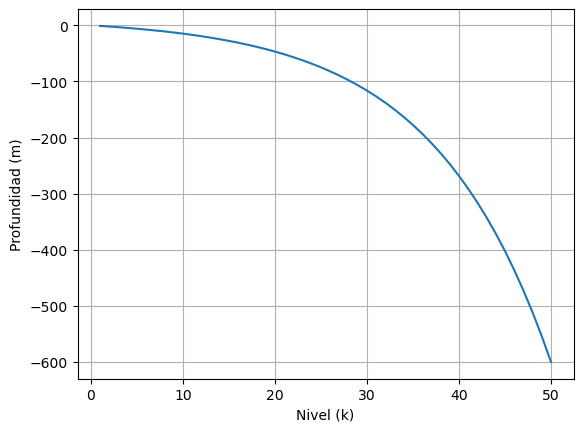

In [3]:
import numpy as np
import matplotlib.pyplot as plt
DelR=(1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.9, 
	2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.5, 
	3.8, 4.1, 4.4, 4.8, 5.2, 5.6, 6.0, 6.5, 
	7.1, 7.6, 8.2, 8.9, 9.6, 10.4, 11.3, 12.2, 
	13.2, 14.3, 15.4, 16.7, 18.0, 19.5, 21.1, 22.8, 
	24.6, 26.6, 28.8, 31.1, 33.7, 36.4, 39.3, 42.5, 
	45.8)
Z=-np.cumsum(DelR)
plt.plot(np.arange(1,51),Z )
plt.xlabel('Nivel (k)')
plt.ylabel('Profundidad (m)')
#plt.title('Niveles verticales (Z) vs Nivel (k)')
plt.grid()
#plt.gca().invert_yaxis()    
plt.show()

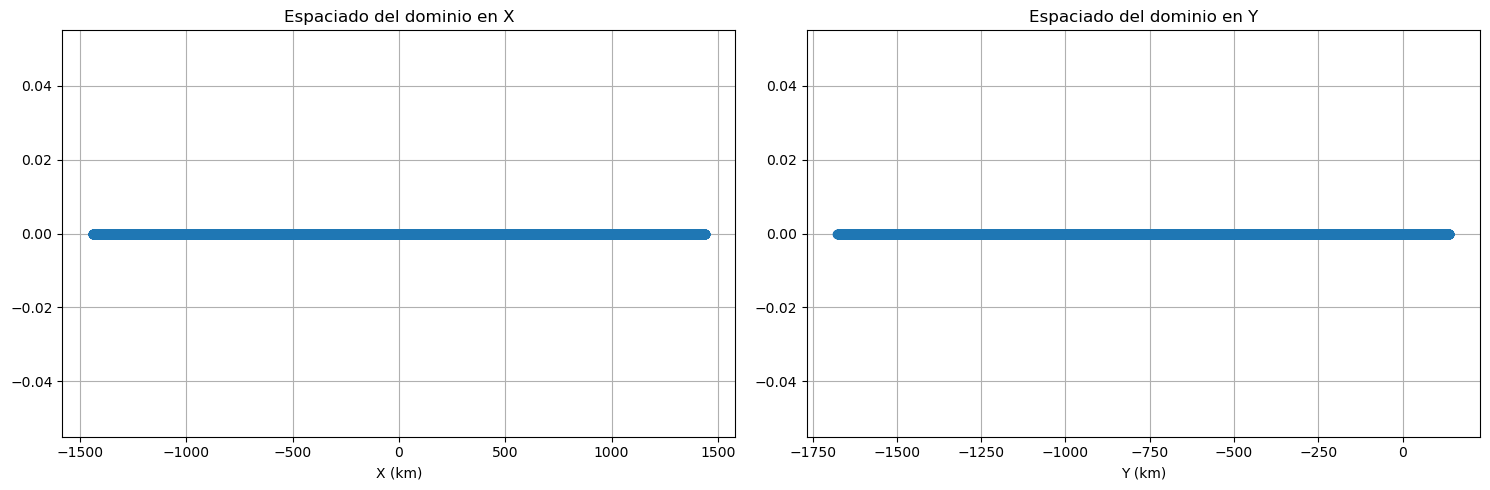

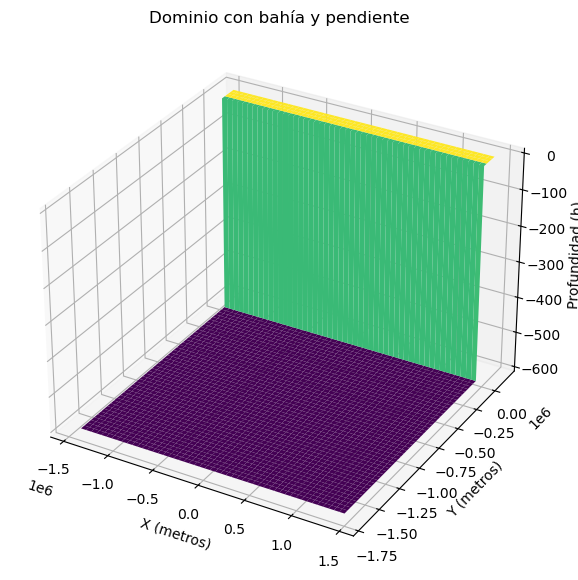

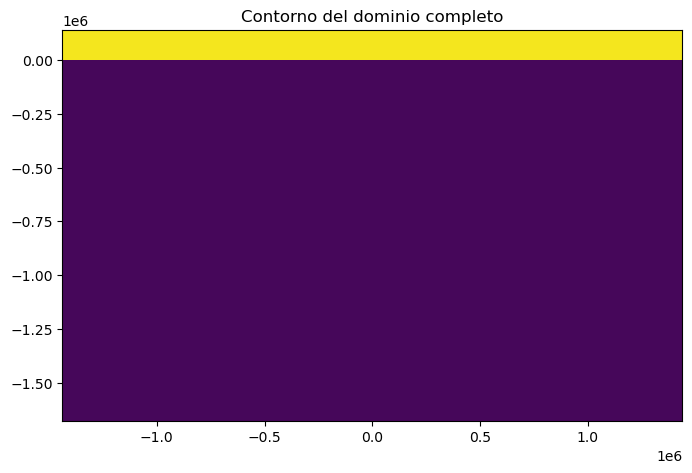

Datos guardados exitosamente en nobay_expand_bat.nc
1.0, 1.0, 1.1, 1.1, 1.2, 1.2, 1.3, 1.3, 1.4, 1.5, 
1.5, 1.6, 1.7, 1.7, 1.8, 1.9, 2.0, 2.0, 2.1, 
2.2, 2.3, 2.4, 2.5, 2.6, 2.7, 2.9, 3.0, 3.1, 
3.2, 3.4, 3.5, 3.7, 3.8, 4.0, 4.2, 4.4, 4.5, 
4.7, 4.9, 5.2, 5.4, 5.6, 5.8, 6.1, 6.4, 6.6, 
6.9, 7.2, 7.5, 7.8, 8.2, 8.5, 8.9, 9.3, 9.7, 
10.1, 10.5, 11.0, 11.4, 11.9, 12.5, 13.0, 13.5, 14.1, 
14.7, 15.4, 16.0, 16.7, 17.4, 18.2, 19.0, 19.8, 20.6, 
21.5, 22.4, 23.4, 24.4, 25.4, 26.5, 27.7, 28.9, 30.1, 
31.4, 32.7, 34.2, 35.6, 37.1, 38.7, 40.5, 42.2, 
Suma total (aprox): 1000.0


In [3]:
# =============================================================================
# Función principal
# =============================================================================
def main_nobay():
    # 1. Obtener parámetros
    params = get_parameters()
    h1, L = params['h1'], params['L']
    Y_fondo, Fondo_lineal = params['Y_fondo'], params['Fondo_lineal']
    DelX, DelY = params['DelX'], params['DelY']
    ny_expand = params['ny_expand']
    
    # Definir Z_max (según el código original)
    Z_max = -1493 - h1  # -1657
    
    # 2. Crear dominio global
    x_domain, y_domain, X_domain, Y_domain, Z_domain, x_left, _, _, _ = create_domain(params)
    
    # Graficar espaciado de los dominios
    plot_domain_spacing(x_domain, y_domain)
    
    # 3. Calcular índices para insertar la bahía y para la pendiente
    Idx_bahia_start = ny_expand + int(np.abs(4*L) / DelY) - 1
    Idx_slope_start = ny_expand + int(np.abs(Fondo_lineal) / DelY) #- 1
    

    # 6. Agregar la pendiente en la región correspondiente
    Z_domain = add_bottom(Z_domain, Idx_bahia_start)
    
    # 7. Suavizar y recortar la batimetría
    Z_domain_crop = crop(Z_domain, crop_value=-600)
    plot_3d_surface(X_domain, Y_domain, Z_domain_crop, title="Dominio con bahía y pendiente")
    
    # Suavizado más fuerte para contornos
    #Z_smooth = gaussian_filter(Z_domain_crop, sigma=15)
    plot_contours(X_domain, Y_domain, Z_domain_crop, title="Contorno del dominio completo")
    
    
    # 8. Guardar datos en NetCDF
    save_netcdf('nobay_expand_bat.nc', X_domain, Y_domain, Z_domain_crop)
    
    # 9. Calcular y mostrar niveles verticales (delR)
    dz, z_levels = compute_vertical_levels()

if __name__ == '__main__':
    main_nobay()

Variables en el archivo netCDF:
{'X': <class 'netCDF4._netCDF4.Variable'>
float32 X(y, x)
    units: meters
    description: Coordenadas X del dominio
unlimited dimensions: 
current shape = (9075, 14378)
filling on, default _FillValue of 9.969209968386869e+36 used, 'Y': <class 'netCDF4._netCDF4.Variable'>
float32 Y(y, x)
    units: meters
    description: Coordenadas Y del dominio
unlimited dimensions: 
current shape = (9075, 14378)
filling on, default _FillValue of 9.969209968386869e+36 used, 'Z': <class 'netCDF4._netCDF4.Variable'>
float32 Z(y, x)
    units: meters
    description: Datos de profundidad del dominio Z
unlimited dimensions: 
current shape = (9075, 14378)
filling on, default _FillValue of 9.969209968386869e+36 used}
Left x-limit: -1438000.0 m, Right x-limit: 1438000.0 m
Bottom y-limit: -1676200.0 m, Top y-limit: 139000.0 m


/var/folders/md/v_9w0p656250q6gw5wc707040000gn/T/ipykernel_2099/965831365.py:87: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  f_interp = sci_interp.interp2d(Xog[0, :], Yog[:, 0], Z)
/var/folders/md/v_9w0p656250q6gw5wc707040000gn/T/ipykernel_2099/965831365.py:88: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids 

Forma de la batimetría interpolada: (352, 560)


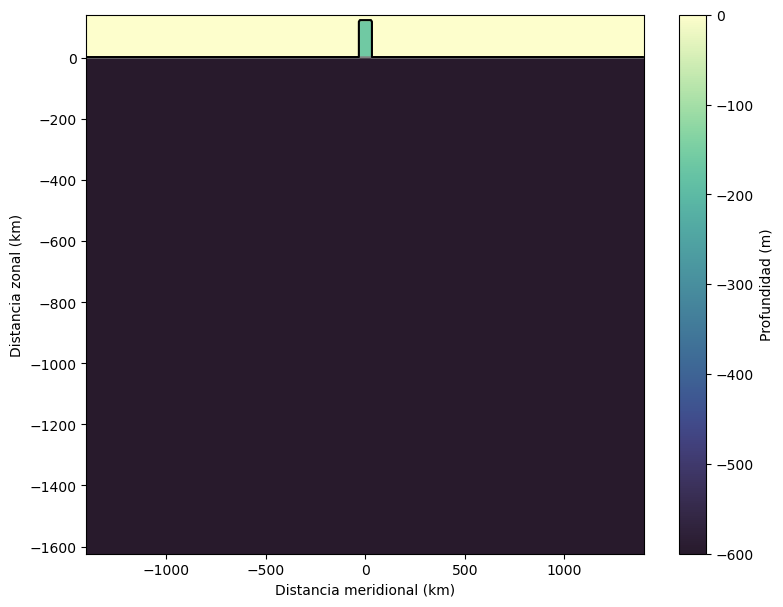

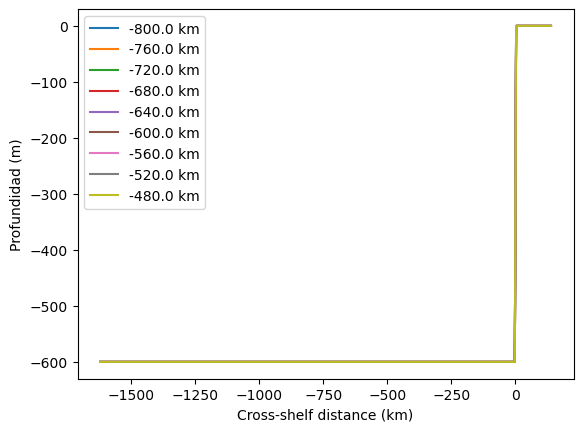

dx: [5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5

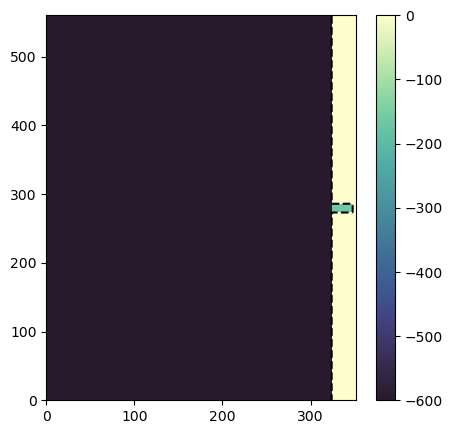

Parámetros MITgcm:
sNx = 17, sNy = 20, OLx = 3, OLy = 3
nSx = 16, nSy = 16, nPx = 1, nPy = 1
Nx = 272
Ny = 320
Parámetros del dominio:
X_N= 560, Y_N = 352
x_min = -1400.0 km, x_max = 1400.0 km
y_min = -1621.0 km, y_max = 139.0 km
DelX = 5.0 km, DelY = 5.0 km


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import cmocean as cmo
import scipy.interpolate as sci_interp

# =============================================================================
# Función para cargar la batimetría original desde el archivo netCDF
# =============================================================================
def load_original_bathy(nc_file):
    """
    Carga la batimetría original desde el archivo netCDF.
    Retorna Xog, Yog y Z (la batimetría suavizada).
    """
    with Dataset(nc_file, 'r') as ds:
        print("Variables en el archivo netCDF:")
        print(ds.variables)
        Xog = ds.variables['X'][:].data
        Yog = ds.variables['Y'][:].data
        Z = ds.variables['Z'][:].data
    print(f'Left x-limit: {np.min(Xog)} m, Right x-limit: {np.max(Xog)} m')
    print(f'Bottom y-limit: {np.min(Yog)} m, Top y-limit: {np.max(Yog)} m')
    return Xog, Yog, Z

# =============================================================================
# Función para construir el nuevo dominio (vectores x y y) con crecimiento cuadrático
# =============================================================================
def build_new_domain(nx_center=96, ny=123, 
                     x_min_center=-240e3, x_max_center=240e3,
                     x_min_expand=-1438e3, x_max_expand=1438e3,
                     y_min=-476e3, y_min_expand=-16762e2, y_max=139e3,
                     factor=1):
    """
    Construye los vectores de dominio nuevos (x_vect y y_vect) para la batimetría.
    Se utiliza crecimiento iterativo con factor en las regiones de expansión,
    garantizando que el primer paso junto al centro sea Δ = DelX y el último
    alcance o supere el límite de expansión.
    """
    # Calcular DelX basado en el dominio central (≈2000 m)
    DelX = (2 * x_max_center) / nx_center
    DelY = DelX  # Mismo espaciado base en Y

    # Extensiones deseadas desde el borde central
    target_x = x_max_expand - x_max_center
    target_y = abs(y_min_expand - y_min)

    # Generar incrementos iterativos de DX hasta alcanzar target_x
    dx = [DelX]
    while sum(dx) < target_x:
        dx.append(dx[-1] * factor)
    dx = np.array(dx)
    x_offsets = np.cumsum(dx)

    # Generar incrementos iterativos de DY hasta alcanzar target_y
    dy = [DelY]
    while sum(dy) < target_y:
        dy.append(dy[-1] * factor)
    dy = np.array(dy)
    y_offsets = np.cumsum(dy)

    # Crear dominios de expansión con Δ crecientes desde el centro hacia el extremo
    x_left  = x_min_center - x_offsets[::-1]   # invertido para recorrer de más lejano a más cercano
    x_right = x_max_center + x_offsets        # desde más cercano al centro hacia el extremo
    y_expand = y_min - y_offsets[::-1]        # invertido para Y expansion hacia abajo

    # Dominio central en X y Y
    x_center = np.round(np.linspace(x_min_center, x_max_center, nx_center), 1)
    y_center = np.round(np.linspace(y_min, y_max, ny), 1)

    # Unir las regiones de izquierda, centro y derecha
    x_vect = np.concatenate((x_left, x_center, x_right))
    y_vect = np.concatenate((y_expand, y_center))

    return x_vect, y_vect, DelX



# =============================================================================
# Función para interpolar la batimetría al nuevo dominio
# =============================================================================
def interpolate_bathy(Xog, Yog, Z, x_vect, y_vect, crop_rows=9, crop_cols=4):
    """
    Interpola la batimetría original (Z) a los nuevos vectores (x_vect, y_vect)
    usando interp2d de SciPy. Luego se recorta la matriz para obtener las
    dimensiones deseadas (nx=272 y ny=320).
    """
    f_interp = sci_interp.interp2d(Xog[0, :], Yog[:, 0], Z)
    bathy = f_interp(x_vect, y_vect)
    # Recortar para ajustar el número de filas (ny)
    bathy = bathy[crop_rows:, :]
    y_vect = y_vect[crop_rows:]
    x_vect = x_vect[crop_cols:-crop_cols]  # Recortar columnas para ajustar nx
    bathy = bathy[:, crop_cols:-crop_cols]  # Recortar columnas de la batimetría
    return bathy, y_vect, x_vect

# =============================================================================
# Función para graficar la batimetría interpolada
# =============================================================================
def plot_bathy(x_vect, y_vect, bathy, filename=None):
    """
    Grafica la batimetría interpolada usando pcolormesh y contornos.
    Si se proporciona un nombre de archivo, guarda la figura en PNG.
    """
    fig, ax = plt.subplots(figsize=(9,7))
    pc = ax.pcolormesh(x_vect/1000, y_vect/1000, bathy, cmap=cmo.cm.deep_r)
    cb = plt.colorbar(pc, ax=ax)
    ax.contour(x_vect/1000, y_vect/1000, -bathy, colors='0.5', levels=[250])
    ax.contour(x_vect/1000, y_vect/1000, -bathy, colors='k', levels=[0])
    cb.set_label('Profundidad (m)')
    ax.set_xlabel('Distancia meridional (km)')
    ax.set_ylabel('Distancia zonal (km)')
    #ax.set_aspect(1)
    if filename:
        plt.savefig(filename, dpi=300)
    plt.show()

# =============================================================================
# Función para graficar perfiles transversales (cross-shelf)
# =============================================================================
def plot_cross_shelf_profiles(x_vect, y_vect, bathy, start=120, stop=186, step=8):
    """
    Grafica perfiles transversales a partir de índices especificados, mostrando
    la variación de la batimetría a lo largo de la dirección cross-shelf.
    """
    for ii in range(start, stop, step):
        plt.plot(y_vect/1e3, bathy[:, ii], label=f'{x_vect[ii]/1e3:1.1f} km')
    plt.legend()
    plt.xlabel('Cross-shelf distance (km)')
    plt.ylabel('Profundidad (m)')
    plt.show()

# =============================================================================
# Función para calcular los vectores de espaciado (dx y dy)
# =============================================================================
def compute_grid_spacing(x_vect, y_vect):
    """
    Calcula los vectores de espaciado dx y dy a partir de x_vect y y_vect.
    """
    delx = x_vect[1:] - x_vect[:-1]
    dely = y_vect[1:] - y_vect[:-1]
    dx = np.append(delx, [delx[-1]])
    dy = np.append(dely, [dely[-1]])
    print("dx:", dx)
    print("dy:", dy)
    return dx, dy

# =============================================================================
# Función para guardar los datos en archivos binarios
# =============================================================================
def save_binary_files(dx, dy, bathy, dx_fname, dy_fname, bathy_fname, dt=np.dtype('>f8')):
    """
    Guarda en archivos binarios los vectores de espaciado (dx y dy) y la batimetría.
    """
    with open(dx_fname, 'wb') as f:
        dx.astype(dt).tofile(f, "")
    with open(dy_fname, 'wb') as f:
        dy.astype(dt).tofile(f, "")
    with open(bathy_fname, 'wb') as f:
        bathy.astype(dt).tofile(f, "")
    print(f"Archivos binarios guardados: {dx_fname}, {dy_fname}, {bathy_fname}")

# =============================================================================
# Función para verificar la correcta escritura del archivo binario de batimetría
# =============================================================================
def verify_binary_file(bathy_fname, x_vect, y_vect, dt=np.dtype('>f8')):
    """
    Lee el archivo binario de batimetría, lo reestructura y lo grafica para
    verificar que se haya guardado correctamente.
    """
    cc = np.fromfile(bathy_fname, dtype=dt)
    nx = len(x_vect)
    ny = len(y_vect)
    bF = np.reshape(cc, (nx, ny), order='F')  # Orden Fortran
    fig, ax = plt.subplots(figsize=(5,5))
    pc = ax.pcolormesh(bF, cmap=cmo.cm.deep_r)
    plt.colorbar(pc, ax=ax)
    ax.contour(bF, levels=[-20, 0], colors='k')
    plt.show()

# =============================================================================
# Función para imprimir los parámetros del dominio para MITgcm
# =============================================================================
def print_mitgcm_params(sNx=17, sNy=20, OLx=3, OLy=3, nSx=16, nSy=16, nPx=1, nPy=1):
    """
    Calcula y muestra los parámetros del dominio de MITgcm.
    """
    Nx = sNx * nSx * nPx
    Ny = sNy * nSy * nPy
    print("Parámetros MITgcm:")
    print(f"sNx = {sNx}, sNy = {sNy}, OLx = {OLx}, OLy = {OLy}")
    print(f"nSx = {nSx}, nSy = {nSy}, nPx = {nPx}, nPy = {nPy}")
    print(f"Nx = {Nx}")
    print(f"Ny = {Ny}")

# =============================================================================
# Función principal
# =============================================================================
def makebin_bay():
    # Archivo netCDF de batimetría original
    nc_file = 'bahia01_expand_bat.nc'
    
    # 1. Cargar batimetría original
    Xog, Yog, Z = load_original_bathy(nc_file)
    
    # 2. Construir el nuevo dominio
    x_vect, y_vect, DelX = build_new_domain()
    
    # 3. Interpolar la batimetría al nuevo dominio
    bathy, y_vect, x_vect = interpolate_bathy(Xog, Yog, Z, x_vect, y_vect, crop_rows=12, crop_cols=8)
    print("Forma de la batimetría interpolada:", bathy.shape)
    
    # 4. Graficar la batimetría interpolada y guardar la figura
    plot_bathy(x_vect, y_vect, bathy, filename="dominio_bath.png")
    
    # 5. Graficar perfiles cross-shelf
    plot_cross_shelf_profiles(x_vect, y_vect, bathy, start=120, stop=186, step=8)
    
    # 6. Calcular vectores de espaciado dx y dy
    dx, dy = compute_grid_spacing(x_vect, y_vect)
    
    # 7. Guardar archivos binarios
    bathy_fname = 'bahia_01_expand_bat.bin'
    dx_fname = 'bahia_01_expand_dx.bin'
    dy_fname = 'bahia_01_expand_dy.bin'
    save_binary_files(dx, dy, bathy, dx_fname, dy_fname, bathy_fname)
    
    # 8. Verificar el archivo binario de batimetría
    verify_binary_file(bathy_fname, x_vect, y_vect)
    
    # 9. Imprimir parámetros del dominio para MITgcm
    print_mitgcm_params()
    print("Parámetros del dominio:")
    print(f"X_N= {len(x_vect)}, Y_N = {len(y_vect)}")
    print(f"x_min = {np.min(x_vect)/1E3} km, x_max = {np.max(x_vect)/1E3} km")
    print(f"y_min = {np.min(y_vect)/1E3} km, y_max = {np.max(y_vect)/1E3} km")
    print(f"DelX = {DelX/1E3} km, DelY = {np.abs(y_vect[1] - y_vect[0])/1E3} km")

if __name__ == '__main__':
    makebin_bay()


Variables en el archivo netCDF:
{'X': <class 'netCDF4._netCDF4.Variable'>
float32 X(y, x)
    units: meters
    description: Coordenadas X del dominio
unlimited dimensions: 
current shape = (9075, 14378)
filling on, default _FillValue of 9.969209968386869e+36 used, 'Y': <class 'netCDF4._netCDF4.Variable'>
float32 Y(y, x)
    units: meters
    description: Coordenadas Y del dominio
unlimited dimensions: 
current shape = (9075, 14378)
filling on, default _FillValue of 9.969209968386869e+36 used, 'Z': <class 'netCDF4._netCDF4.Variable'>
float32 Z(y, x)
    units: meters
    description: Datos de profundidad del dominio Z
unlimited dimensions: 
current shape = (9075, 14378)
filling on, default _FillValue of 9.969209968386869e+36 used}
Left x-limit: -1438000.0 m, Right x-limit: 1438000.0 m
Bottom y-limit: -1676200.0 m, Top y-limit: 139000.0 m


/var/folders/md/v_9w0p656250q6gw5wc707040000gn/T/ipykernel_2099/965831365.py:87: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  f_interp = sci_interp.interp2d(Xog[0, :], Yog[:, 0], Z)
/var/folders/md/v_9w0p656250q6gw5wc707040000gn/T/ipykernel_2099/965831365.py:88: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids 

Forma de la batimetría interpolada: (352, 560)


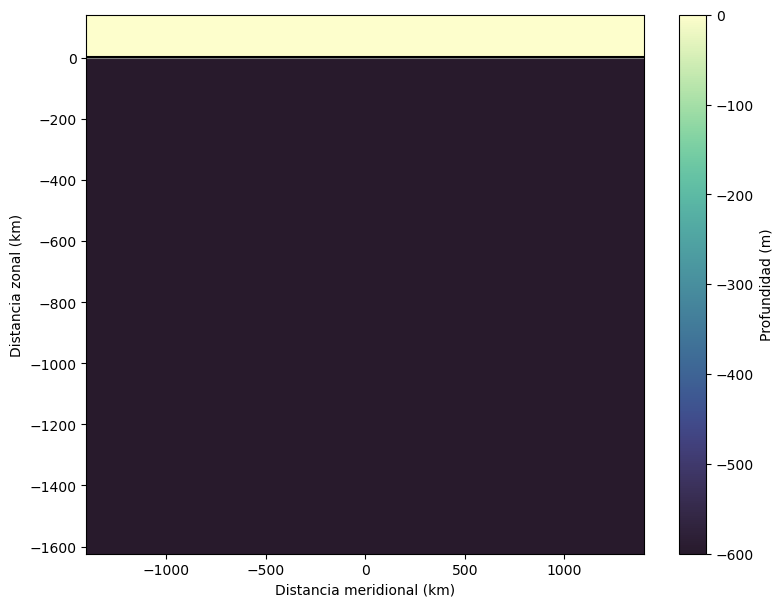

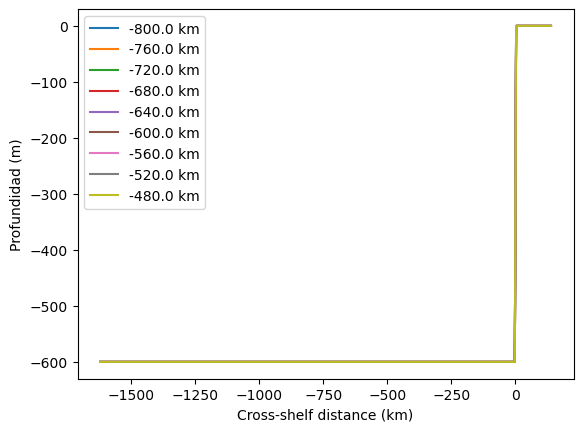

dx: [5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.  5000.
 5000.  5000.  5

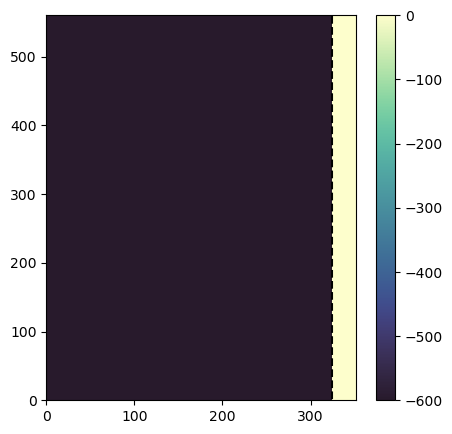

Parámetros MITgcm:
sNx = 17, sNy = 20, OLx = 3, OLy = 3
nSx = 16, nSy = 16, nPx = 1, nPy = 1
Nx = 272
Ny = 320


In [5]:
def makebin_nobay():
    # Archivo netCDF de batimetría original
    nc_file = 'nobay_expand_bat.nc'
    
    # 1. Cargar batimetría original
    Xog, Yog, Z = load_original_bathy(nc_file)
    
    # 2. Construir el nuevo dominio
    x_vect, y_vect, DelX = build_new_domain()
    
    # 3. Interpolar la batimetría al nuevo dominio
    bathy, y_vect, x_vect = interpolate_bathy(Xog, Yog, Z, x_vect, y_vect, crop_rows=12, crop_cols=8)
    print("Forma de la batimetría interpolada:", bathy.shape)
    
    # 4. Graficar la batimetría interpolada y guardar la figura
    plot_bathy(x_vect, y_vect, bathy, filename="dominio_bath_nobay.png")
    
    # 5. Graficar perfiles cross-shelf
    plot_cross_shelf_profiles(x_vect, y_vect, bathy, start=120, stop=186, step=8)
    
    # 6. Calcular vectores de espaciado dx y dy
    dx, dy = compute_grid_spacing(x_vect, y_vect)
    
    # 7. Guardar archivos binarios
    bathy_fname = 'nobahia_01_expand_bat.bin'
    dx_fname = 'nobahia_01_expand_dx.bin'
    dy_fname = 'nobahia_01_expand_dy.bin'
    save_binary_files(dx, dy, bathy, dx_fname, dy_fname, bathy_fname)
    
    # 8. Verificar el archivo binario de batimetría
    verify_binary_file(bathy_fname, x_vect, y_vect)
    
    # 9. Imprimir parámetros del dominio para MITgcm
    print_mitgcm_params()

if __name__ == '__main__':
    makebin_nobay()


In [9]:
nx_center=238
ny=320
y_min=-476e3
y_max=139e3
dely = 2000  # Espaciado en Y
ny= int((y_max - y_min) / dely)
print("ny:", ny)
y_center = np.round(np.linspace(y_min, y_max, ny), decimals=1)
dely = y_center[1:] - y_center[:-1]
print("dely:", dely)
print("dely[-1]:", dely[-1])

ny: 307
dely: [2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.9 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.9 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.9 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.9
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.9 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8
 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8 2009.8

In [10]:
x_min_center=-238e3
x_max_center=238e3
x_center = np.round(np.linspace(x_min_center, x_max_center, nx_center), decimals=1)
print("x_center:", x_center)
delx = x_center[1:] - x_center[:-1]
print("delx:", delx)
print("delx[-1]:", delx[-1])

x_center: [-238000.  -235991.6 -233983.1 -231974.7 -229966.2 -227957.8 -225949.4
 -223940.9 -221932.5 -219924.1 -217915.6 -215907.2 -213898.7 -211890.3
 -209881.9 -207873.4 -205865.  -203856.5 -201848.1 -199839.7 -197831.2
 -195822.8 -193814.3 -191805.9 -189797.5 -187789.  -185780.6 -183772.2
 -181763.7 -179755.3 -177746.8 -175738.4 -173730.  -171721.5 -169713.1
 -167704.6 -165696.2 -163687.8 -161679.3 -159670.9 -157662.4 -155654.
 -153645.6 -151637.1 -149628.7 -147620.3 -145611.8 -143603.4 -141594.9
 -139586.5 -137578.1 -135569.6 -133561.2 -131552.7 -129544.3 -127535.9
 -125527.4 -123519.  -121510.5 -119502.1 -117493.7 -115485.2 -113476.8
 -111468.4 -109459.9 -107451.5 -105443.  -103434.6 -101426.2  -99417.7
  -97409.3  -95400.8  -93392.4  -91384.   -89375.5  -87367.1  -85358.6
  -83350.2  -81341.8  -79333.3  -77324.9  -75316.5  -73308.   -71299.6
  -69291.1  -67282.7  -65274.3  -63265.8  -61257.4  -59248.9  -57240.5
  -55232.1  -53223.6  -51215.2  -49206.8  -47198.3  -45189.9  -43181

In [15]:
y_min_expand=-5169535
DelX = int((2 * x_max_center) / nx_center)
k = DelX  # Factor para crecimiento cuadrático
int(((np.abs(y_min_expand) - np.abs(y_min)) / k)**(1/2.5)) + 1
print("i_values_y:", int(((np.abs(y_min_expand) - np.abs(y_min)) / k)**(1/2.5)) + 1)
i_values_y = np.arange(1, int(((np.abs(y_min_expand) - np.abs(y_min)) / k)**(1/2.5)) + 1)
y_expand = y_min - k * (i_values_y**2.5)
y_expand = np.flip(y_expand)

i_values_y: 23


In [16]:
print("y_expand:", y_expand)
print("y_expand[-1]:", y_expand[-1])
print("y_expand[0]:", y_expand[0])

y_expand: [-5016322.45550908 -4517831.76295105 -4053708.76399966 -3623125.03723637
 -3225231.1652533  -2859155.05160701 -2524000.         -2218842.50579334
 -1942729.69561538 -1694676.33110683 -1473661.26515967 -1278623.19926601
 -1108455.53203368  -962000.          -838038.67196751  -735283.62848433
  -652363.26148039  -587803.39887499  -540000.          -507176.91453624
  -487313.70849898  -478000.        ]
y_expand[-1]: -478000.0
y_expand[0]: -5016322.455509081


In [7]:
nSx = 16
Nx= 574
sNx = Nx // nSx
print("sNx:", sNx)
Nx_new = sNx * nSx
print("Nx_new:", Nx_new)
print("Nx:", Nx)

sNx: 35
Nx_new: 560
Nx: 574


In [1]:
272//2

136

In [11]:
nSy = 16
Ny = 364
sNy = Ny // nSy
print("sNy:", sNy)
Ny_new = sNy * nSy
print("Ny_new:", Ny_new)
print("Ny:", Ny)

sNy: 22
Ny_new: 352
Ny: 364


## Máscara para subdominio

In [1]:
import os
import numpy as np

# Parámetros del dominio
NY, NX = 352, 560

# Ajusta estos índices según el subdominio que quieras recortar
# Filas (Y): desde row_start hasta row_end (inclusive)
row_start, row_end = 250, 352
# Columnas (X): desde col_start hasta col_end (inclusive)
col_start, col_end = (NX//2) - 100, (NX//2) + 100 

# Inicializa máscara de ceros
mask = np.zeros((NY, NX), dtype='>f8')

# Asigna valor 1 dentro del subdominio
mask[row_start:row_end+1, col_start:col_end+1] = 1.0

# Guarda en big-endian float32, orden C (fila por fila)
outname = 'subdomain_mask.bin'
mask.ravel(order='c').tofile(outname)
print(f'Máscara guardada en {outname} con forma {mask.shape}')



Máscara guardada en subdomain_mask.bin con forma (352, 560)


In [4]:
import os
import numpy as np

# 1) Parámetros de tu dominio
NY, NX = 352, 560
domain_shape = (NY, NX)

# 2) Define tu subdominio en índices válidos [0..NY-1], [0..NX-1]
min_row = 100           # ejemplo: empieza en fila 100
max_row = 300           # termina en fila 300 (<= 351)
mid_col = NX // 2       # columna central = 280
min_col = mid_col - 100 # 180
max_col = mid_col + 100 # 380

# función auxiliar para escribir cada máscara
def write_mask(mask, fname):
    mask.astype('>f8').ravel(order='F').tofile(fname)
    print(f'  → {fname}  (shape {mask.shape}, dtype >f8, F-order)')

# 3) Máscara lateral este: columnas = max_col
mask = np.zeros(domain_shape, dtype='>f8')
cnt = 1
for row in range(min_row, max_row+1):
    mask[row, max_col] = cnt; cnt += 1
write_mask(mask, 'lateral_mask_east.bin')

# 4) Máscara lateral oeste: columnas = min_col
mask = np.zeros(domain_shape, dtype='>f8')
cnt = 1
for row in range(min_row, max_row+1):
    mask[row, min_col] = cnt; cnt += 1
write_mask(mask, 'lateral_mask_west.bin')

# 5) Máscara lateral sur: fila = min_row
mask = np.zeros(domain_shape, dtype='>f8')
cnt = 1
for col in range(min_col, max_col+1):
    mask[min_row, col] = cnt; cnt += 1
write_mask(mask, 'lateral_mask_south.bin')

# 6) Máscara lateral norte: fila = max_row
mask = np.zeros(domain_shape, dtype='>f8')
cnt = 1
for col in range(min_col, max_col+1):
    mask[max_row, col] = cnt; cnt += 1
write_mask(mask, 'lateral_mask_north.bin')

# 7) Máscara de superficie interior
mask = np.zeros(domain_shape, dtype='>f8')
cnt = 1
for row in range(min_row, max_row+1):
    for col in range(min_col, max_col+1):
        mask[row, col] = cnt; cnt += 1
write_mask(mask, 'surface_mask.bin')


  → lateral_mask_east.bin  (shape (352, 560), dtype >f8, F-order)
  → lateral_mask_west.bin  (shape (352, 560), dtype >f8, F-order)
  → lateral_mask_south.bin  (shape (352, 560), dtype >f8, F-order)
  → lateral_mask_north.bin  (shape (352, 560), dtype >f8, F-order)
  → surface_mask.bin  (shape (352, 560), dtype >f8, F-order)


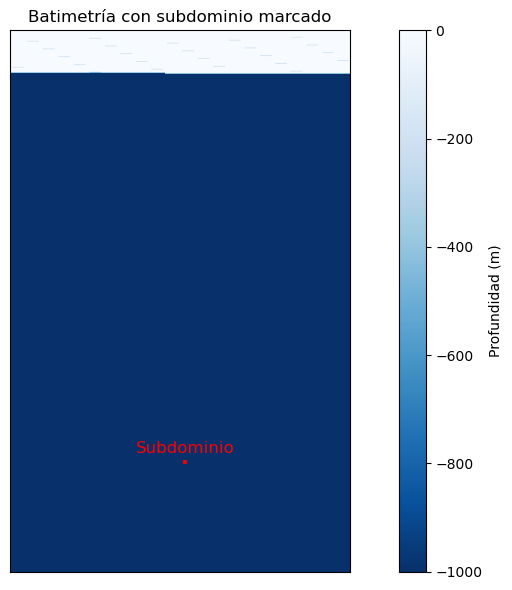

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Dominio
NY, NX = 352, 560

# Rutas a archivos
bathy_file = 'bahia_01_expand_bat.bin'   # tu batimetría (big-endian float32)
mask_file  = 'surface_mask.bin'

# Carga batimetría
bathy = np.fromfile(bathy_file, dtype='>f8').reshape((NY, NX), order='F')

# Carga máscara
mask  = np.fromfile(mask_file, dtype='>f8').reshape((NY, NX), order='C')

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(bathy.T, origin='lower', cmap='Blues_r')
cbar = fig.colorbar(im, ax=ax, label='Profundidad (m)')
ax.set_title('Batimetría con subdominio marcado')

# Superpón el rectángulo del subdominio
# Encuentra los límites del rectángulo en índices
rows, cols = np.where(mask==1.0)
r0, r1 = rows.min(), rows.max()+1
c0, c1 = cols.min(), cols.max()+1

rect = Rectangle((c0, r0), c1-c0, r1-r0,
                 edgecolor='red', facecolor='none', linewidth=2)
ax.add_patch(rect)
ax.text((c0+c1)/2, r1+5, 'Subdominio', color='red',
        ha='center', va='bottom', fontsize=12)

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()
plt.show()


In [9]:
import numpy as np
data_east = np.fromfile('lateral_mask_east.bin', dtype='>f8')  # o f8 si es
print(data_east.size, 'elementos, esperando', NY*NX)
print(data_east.shape)  # debería ser (NY, NX)
data_east = data_east.reshape((NY, NX), order='F')  # Fortran order
print(data_east.shape)  # debería ser (NY, NX)

#Comprobar las otras máscaras
data_west = np.fromfile('lateral_mask_west.bin', dtype='>f8')
print(data_west.size, 'elementos, esperando', NY*NX)
data_south = np.fromfile('lateral_mask_south.bin', dtype='>f8')
print(data_south.size, 'elementos, esperando', NY*NX)
data_north = np.fromfile('lateral_mask_north.bin', dtype='>f8')
print(data_north.size, 'elementos, esperando', NY*NX)
data_surface = np.fromfile('surface_mask.bin', dtype='>f8')
print(data_surface.size, 'elementos, esperando', NY*NX)




197120 elementos, esperando 197120
(197120,)
(352, 560)
197120 elementos, esperando 197120
197120 elementos, esperando 197120
197120 elementos, esperando 197120
197120 elementos, esperando 197120
